# Exploratory Data Analysis (EDA)

This notebook explores the historical stock data using statistical
summaries and visualizations to understand trends, returns,
volatility, and relationships among the assets.

In [45]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [46]:
df = pd.read_csv("../data/processed/clean_stock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Daily_Return
0,2015-01-05,59.577908,82.889999,82.919998,82.699997,82.739998,5820100,BND,0.002904
1,2015-01-06,59.750416,83.129997,83.379997,83.029999,83.029999,3887600,BND,0.002895
2,2015-01-07,59.786331,83.180000,83.279999,83.050003,83.139999,2433400,BND,0.000602
3,2015-01-08,59.692890,83.050003,83.110001,82.970001,83.110001,1873400,BND,-0.001563
4,2015-01-09,59.793522,83.190002,83.290001,83.000000,83.010002,1646100,BND,0.001686


In [47]:
print(df.info())

print()

print(df.describe())

print()

print(df["Ticker"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8661 entries, 0 to 8660
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          8661 non-null   datetime64[ns]
 1   Adj Close     8661 non-null   float64       
 2   Close         8661 non-null   float64       
 3   High          8661 non-null   float64       
 4   Low           8661 non-null   float64       
 5   Open          8661 non-null   float64       
 6   Volume        8661 non-null   int64         
 7   Ticker        8661 non-null   object        
 8   Daily_Return  8661 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 609.1+ KB
None

                                Date    Adj Close        Close         High  \
count                           8661  8661.000000  8661.000000  8661.000000   
mean   2020-09-27 23:38:33.127814400   188.964803   201.140829   202.901750   
min              2

Price Trend

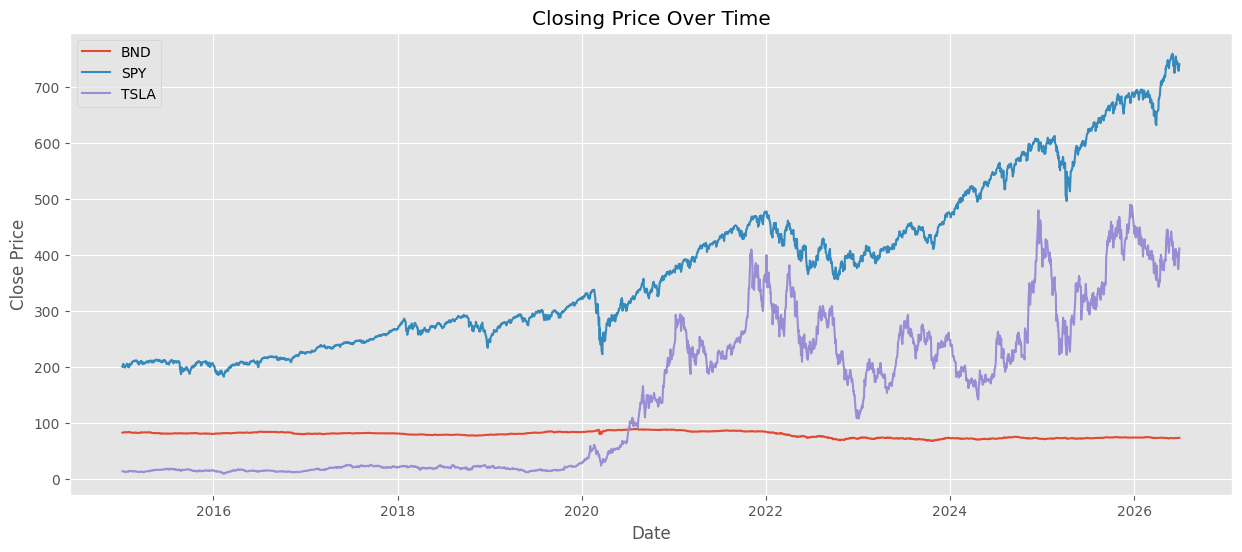

In [48]:
plt.figure(figsize=(15,6))

for ticker in df["Ticker"].unique():

    temp = df[df["Ticker"] == ticker]

    plt.plot(
        temp["Date"],
        temp["Close"],
        label=ticker
    )

plt.title("Closing Price Over Time")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.legend()

plt.show()

Daily Returns

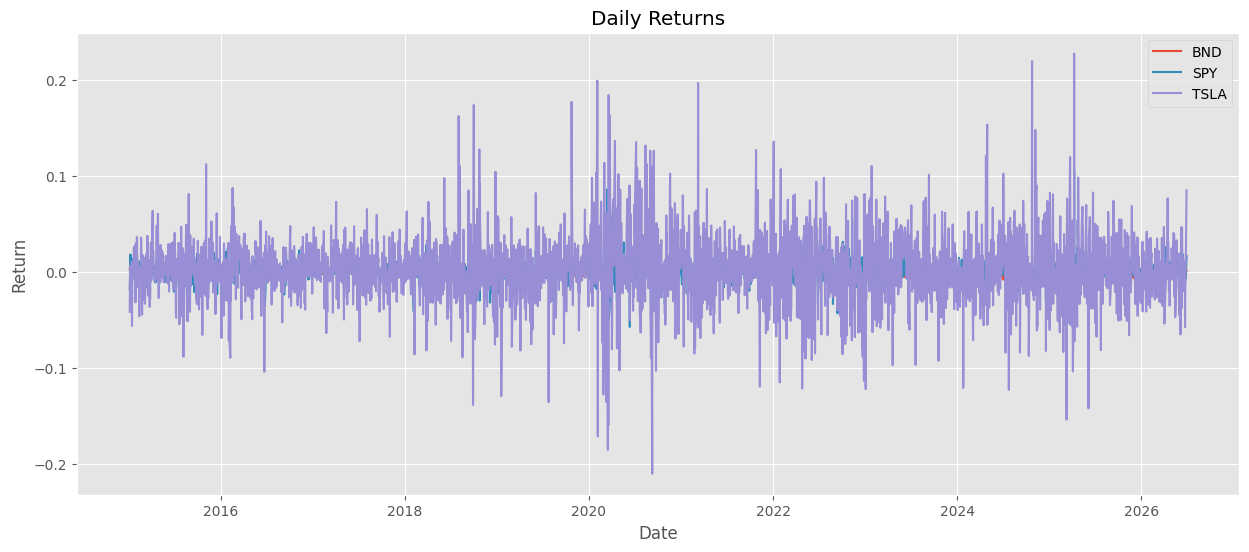

In [49]:
plt.figure(figsize=(15,6))

for ticker in df["Ticker"].unique():

    temp = df[df["Ticker"] == ticker]

    plt.plot(
        temp["Date"],
        temp["Daily_Return"],
        label=ticker
    )

plt.title("Daily Returns")

plt.xlabel("Date")

plt.ylabel("Return")

plt.legend()

plt.show()

Distribution of Daily Returns

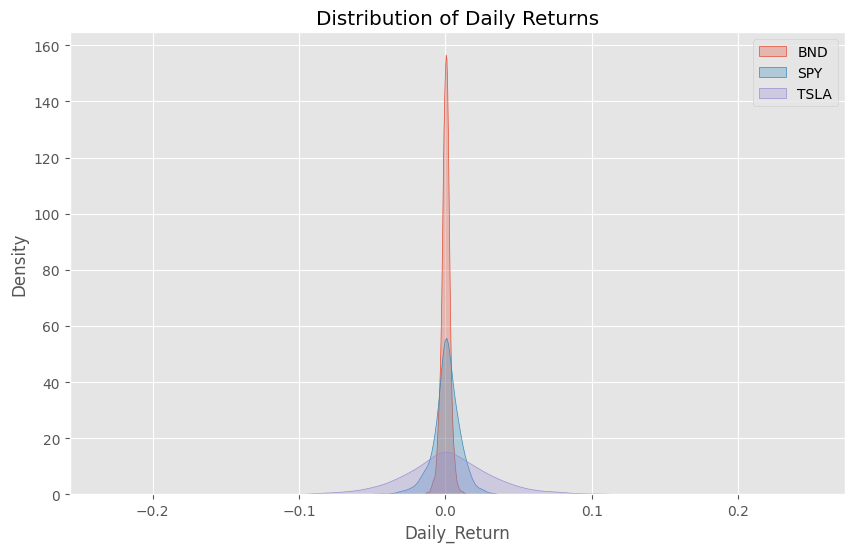

In [50]:
plt.figure(figsize=(10,6))

for ticker in df["Ticker"].unique():

    sns.kdeplot(
        df[df["Ticker"] == ticker]["Daily_Return"],
        label=ticker,
        fill=True,
        alpha=0.3
    )

plt.title("Distribution of Daily Returns")

plt.legend()

plt.show()

Histograms

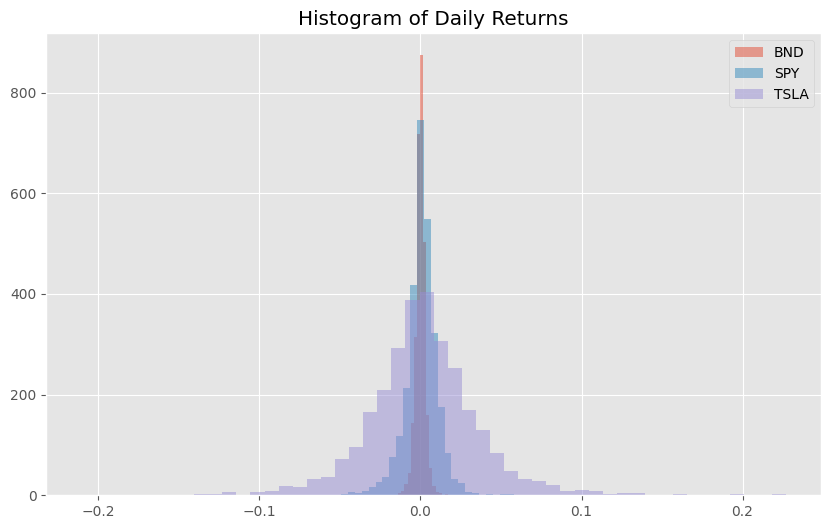

In [51]:
plt.figure(figsize=(10,6))

for ticker in df["Ticker"].unique():

    plt.hist(
        df[df["Ticker"] == ticker]["Daily_Return"],
        bins=50,
        alpha=0.5,
        label=ticker
    )

plt.legend()

plt.title("Histogram of Daily Returns")

plt.show()

Boxplot

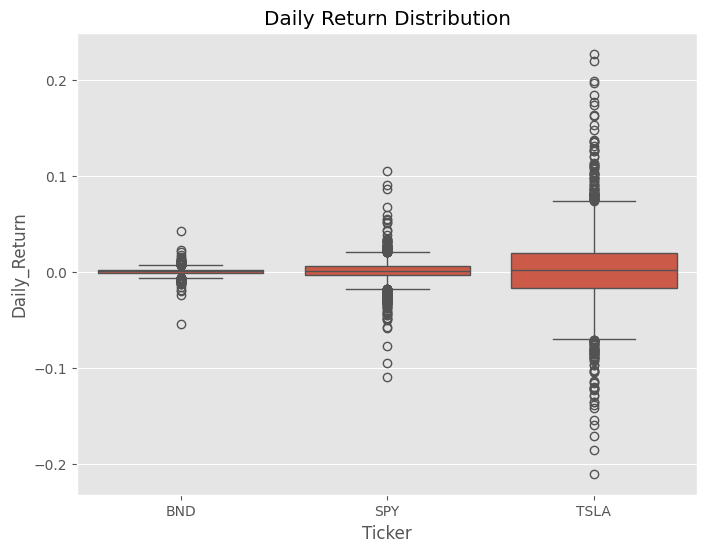

In [30]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Ticker",
    y="Daily_Return"
)

plt.title("Daily Return Distribution")

plt.show()

Average Daily Return

In [31]:
average_return = df.groupby("Ticker")["Daily_Return"].mean()

average_return

Ticker
BND    -0.000034
SPY     0.000507
TSLA    0.001803
Name: Daily_Return, dtype: float64

Standard Deviation (Risk)

In [32]:
risk = df.groupby("Ticker")["Daily_Return"].std()

risk

Ticker
BND     0.003383
SPY     0.011163
TSLA    0.036018
Name: Daily_Return, dtype: float64

Correlation Matrix

In [33]:
pivot = df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Daily_Return"
)

pivot.head()

Ticker,BND,SPY,TSLA
Date,,,
2015-01-05,0.002904,-0.018060,-0.042041
2015-01-06,0.002895,-0.009419,0.005664
2015-01-07,0.000602,0.012461,-0.001562
2015-01-08,-0.001563,0.017745,-0.001564
2015-01-09,0.001686,-0.008014,-0.018802


In [34]:
corr = pivot.corr()

corr

Ticker,BND,SPY,TSLA
Ticker,,,
BND,1.000000,0.109867,0.058409
SPY,0.109867,1.000000,0.491456
TSLA,0.058409,0.491456,1.000000


Heatmap

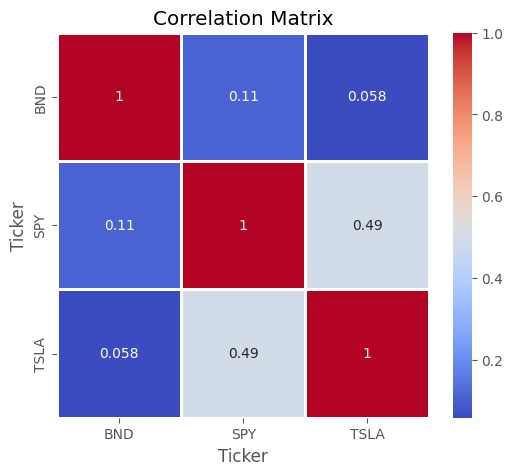

In [35]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Matrix")

plt.show()

Cumulative Returns

In [36]:
df["Cumulative_Return"] = (
    1 + df["Daily_Return"]
).groupby(df["Ticker"]).cumprod()

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Daily_Return,Cumulative_Return
0,2015-01-05,59.577908,82.889999,82.919998,82.699997,82.739998,5820100,BND,0.002904,1.002904
1,2015-01-06,59.750416,83.129997,83.379997,83.029999,83.029999,3887600,BND,0.002895,1.005808
2,2015-01-07,59.786331,83.180000,83.279999,83.050003,83.139999,2433400,BND,0.000602,1.006413
3,2015-01-08,59.692890,83.050003,83.110001,82.970001,83.110001,1873400,BND,-0.001563,1.004840
4,2015-01-09,59.793522,83.190002,83.290001,83.000000,83.010002,1646100,BND,0.001686,1.006534


Plot Cumulative Returns

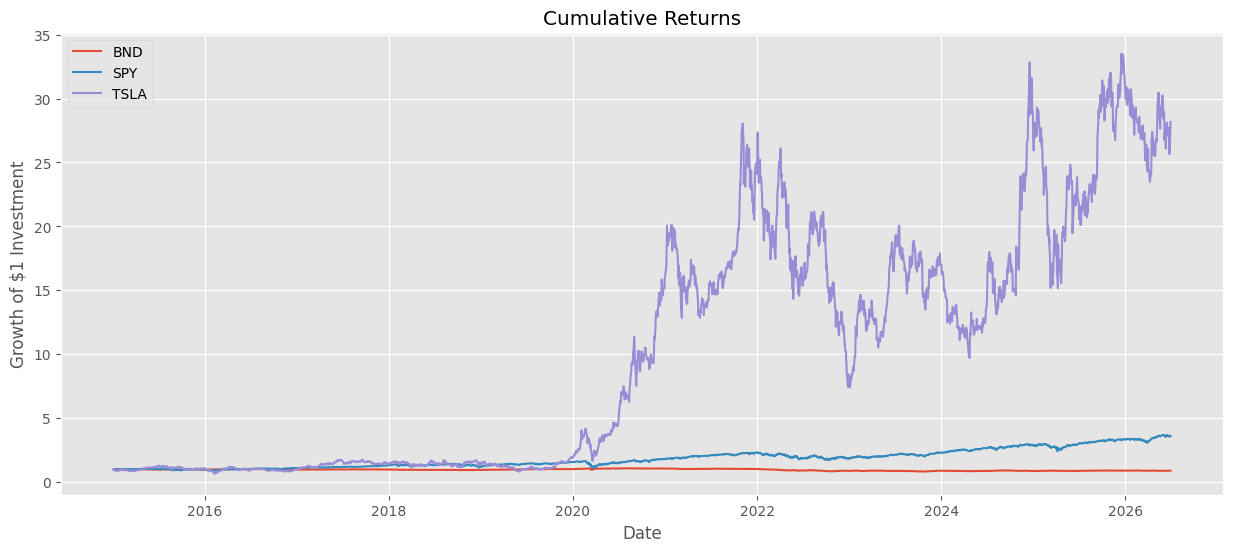

In [37]:
plt.figure(figsize=(15,6))

for ticker in df["Ticker"].unique():

    temp = df[df["Ticker"] == ticker]

    plt.plot(
        temp["Date"],
        temp["Cumulative_Return"],
        label=ticker
    )

plt.title("Cumulative Returns")

plt.xlabel("Date")

plt.ylabel("Growth of $1 Investment")

plt.legend()

plt.show()

Rolling Volatility (30-Day)

In [38]:
df["Rolling_Volatility"] = (
    df.groupby("Ticker")["Daily_Return"]
      .rolling(30)
      .std()
      .reset_index(level=0, drop=True)
)

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Daily_Return,Cumulative_Return,Rolling_Volatility
0,2015-01-05,59.577908,82.889999,82.919998,82.699997,82.739998,5820100,BND,0.002904,1.002904,NaN
1,2015-01-06,59.750416,83.129997,83.379997,83.029999,83.029999,3887600,BND,0.002895,1.005808,NaN
2,2015-01-07,59.786331,83.180000,83.279999,83.050003,83.139999,2433400,BND,0.000602,1.006413,NaN
3,2015-01-08,59.692890,83.050003,83.110001,82.970001,83.110001,1873400,BND,-0.001563,1.004840,NaN
4,2015-01-09,59.793522,83.190002,83.290001,83.000000,83.010002,1646100,BND,0.001686,1.006534,NaN


Plot Rolling Volatility

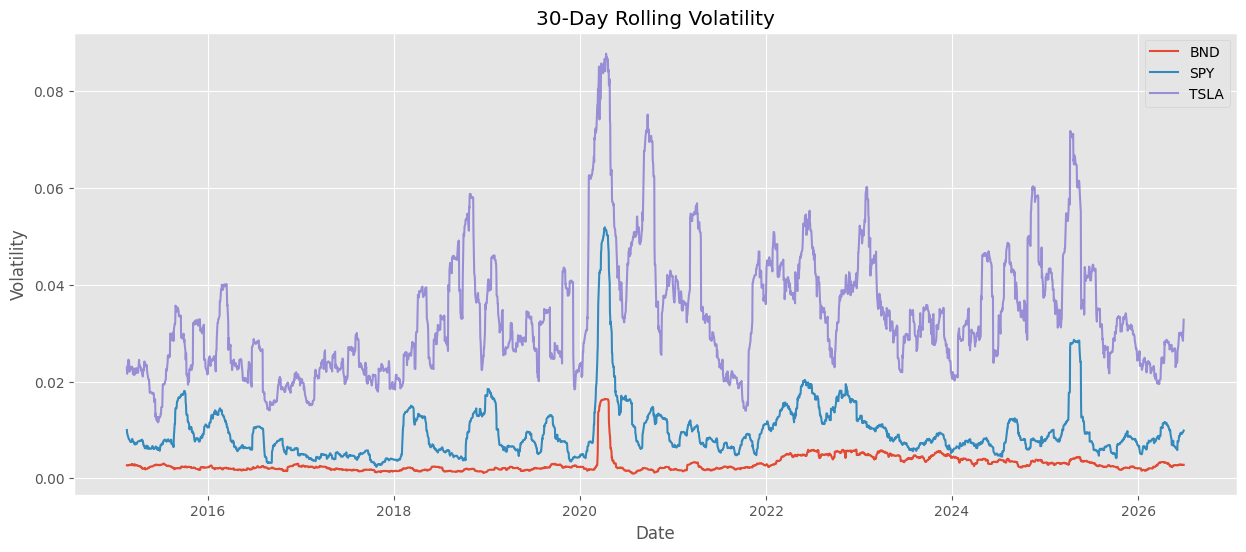

In [39]:
plt.figure(figsize=(15,6))

for ticker in df["Ticker"].unique():

    temp = df[df["Ticker"] == ticker]

    plt.plot(
        temp["Date"],
        temp["Rolling_Volatility"],
        label=ticker
    )

plt.title("30-Day Rolling Volatility")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.legend()

plt.show()

Summary Table

In [40]:
summary = pd.DataFrame({

    "Average Return": average_return,

    "Risk": risk

})

summary

,Average Return,Risk
Ticker,,
BND,-0.000034,0.003383
SPY,0.000507,0.011163
TSLA,0.001803,0.036018


In [41]:
df.to_csv(
    "../data/processed/eda_data.csv",
    index=False
)

In [42]:
import numpy as np

def compute_var(series, confidence=0.05):
    return np.percentile(series.dropna(), confidence * 100)

tickers = df["Ticker"].unique()

for t in tickers:
    returns = df[df["Ticker"] == t]["Daily_Return"]
    var_5 = compute_var(returns, 0.05)
    
    print(f"{t} 5% Historical VaR: {var_5:.4f}")

BND 5% Historical VaR: -0.0051
SPY 5% Historical VaR: -0.0167
TSLA 5% Historical VaR: -0.0517


Value at Risk (VaR) estimates the maximum expected loss at a 95% confidence level. Negative VaR values indicate downside risk thresholds based on historical return distribution.

In [43]:
def detect_outliers(df, threshold=0.05):
    outliers = df[np.abs(df["Daily_Return"]) > threshold]
    return outliers

for t in df["Ticker"].unique():
    outliers = detect_outliers(df[df["Ticker"] == t])
    print(f"\n{t} Outliers (>5% move):", len(outliers))


BND Outliers (>5% move): 1

SPY Outliers (>5% move): 15

TSLA Outliers (>5% move): 353


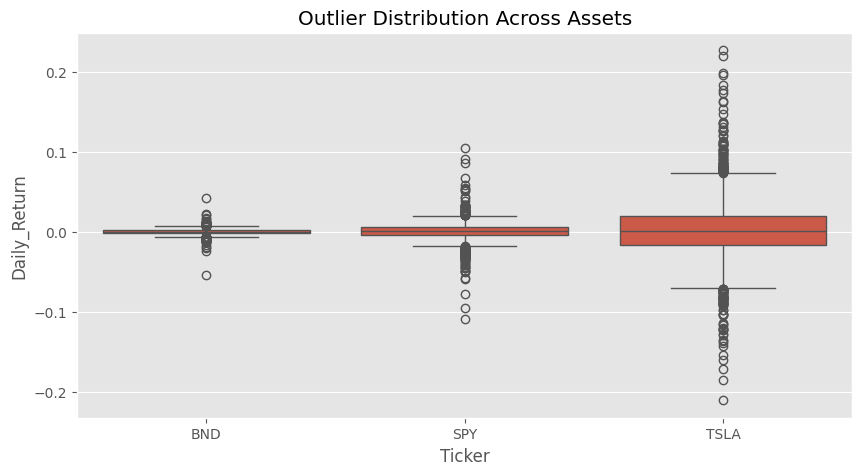

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x="Ticker", y="Daily_Return", data=df)
plt.title("Outlier Distribution Across Assets")
plt.show()

Extreme return events are concentrated in TSLA, reflecting higher volatility compared to SPY and BND. These outliers justify the need for robust risk measures such as VaR and volatility-based modeling.

The exploratory analysis reveals distinct risk profiles across assets. TSLA exhibits significantly higher return dispersion and more frequent extreme movements, while SPY and BND demonstrate lower volatility and more stable return distributions. These characteristics directly influence downstream modeling choices, particularly the suitability of ARIMA and LSTM under varying noise conditions.

Missing values were checked post-cleaning. Any NaNs originate from percentage change computation and are expected. No structural data integrity issues were detected. Outliers are primarily driven by TSLA volatility.

## Key Findings

- TSLA shows the highest return but also the highest volatility.
- SPY demonstrates relatively stable growth with moderate returns.
- BND has the lowest volatility and acts as a defensive asset.
- TSLA and SPY exhibit stronger correlation than BND.
- Rolling volatility indicates periods of increased market uncertainty.

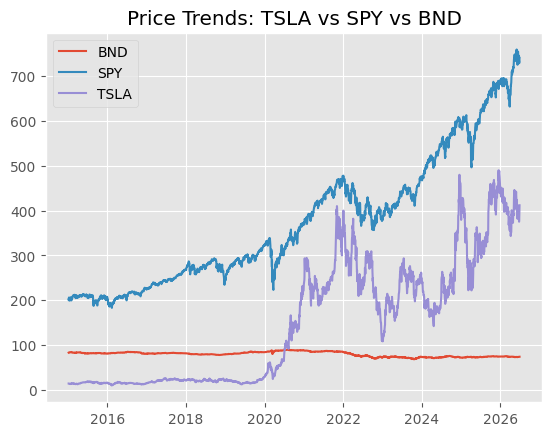

In [ ]:
import matplotlib.pyplot as plt

for t in df["Ticker"].unique():
    subset = df[df["Ticker"] == t]
    plt.plot(subset["Date"], subset["Close"], label=t)

plt.title("Price Trends: TSLA vs SPY vs BND")
plt.legend()
plt.show()

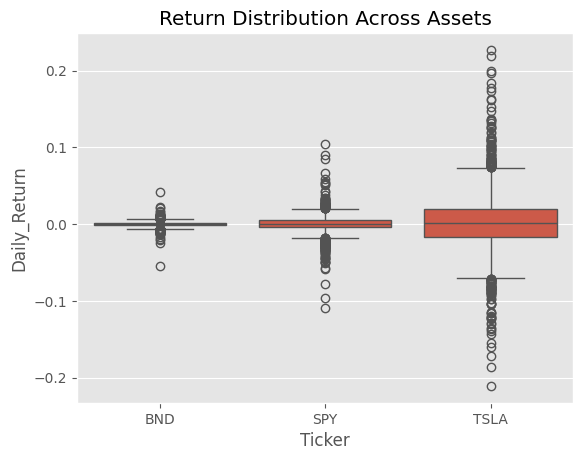

In [53]:
import seaborn as sns

sns.boxplot(x="Ticker", y="Daily_Return", data=df)
plt.title("Return Distribution Across Assets")
plt.show()

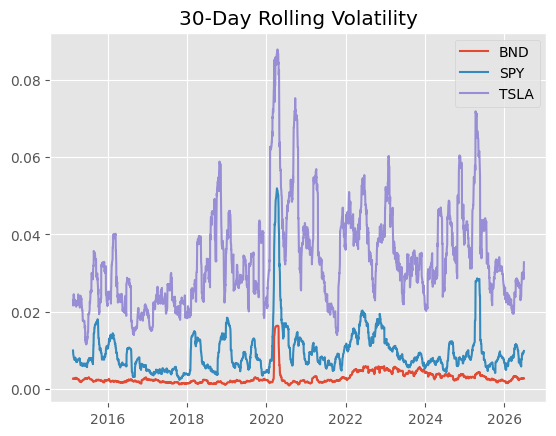

In [54]:
df["Rolling_Vol"] = df.groupby("Ticker")["Daily_Return"].rolling(30).std().reset_index(0, drop=True)

for t in df["Ticker"].unique():
    subset = df[df["Ticker"] == t]
    plt.plot(subset["Date"], subset["Rolling_Vol"], label=t)

plt.title("30-Day Rolling Volatility")
plt.legend()
plt.show()

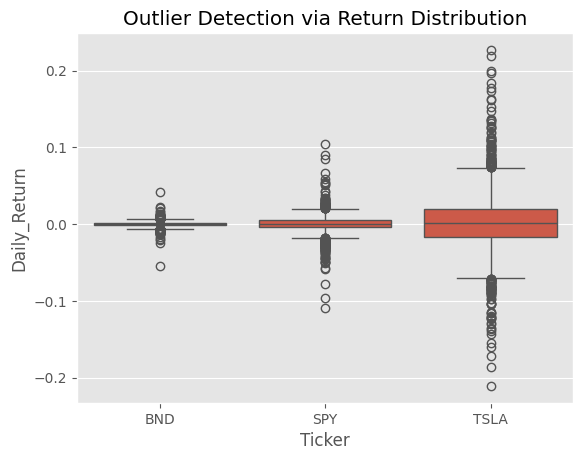

In [55]:
sns.boxplot(x="Ticker", y="Daily_Return", data=df)
plt.title("Outlier Detection via Return Distribution")
plt.show()

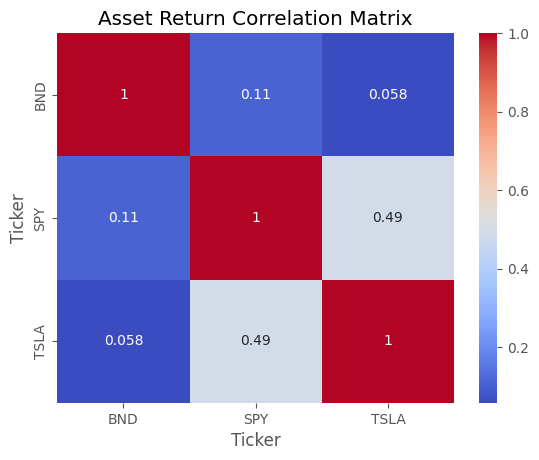

In [57]:
returns = df.pivot(index="Date", columns="Ticker", values="Daily_Return")
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Asset Return Correlation Matrix")
plt.show()